## Notebook for visualizing results from sequential implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
import jax.numpy as jnp
import jax
import json
import os

from NRT_functions import losses
from NRT_functions import helper_functions
from NRT_functions import plotters
from sweep_analysis_sequential import generate_2d_plots, generate_loss_plots

/home/julian/Projects/MasterThesis/ICLR_Actionable_Reps/sweep_analysis_sequential.py:50: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('$\omega_x$', fontsize=12)
/home/julian/Projects/MasterThesis/ICLR_Actionable_Reps/sweep_analysis_sequential.py:51: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel('$\omega_y$', fontsize=12)


In [2]:
filepath = './data/251217/090833'
counter = 0
save_fig = 0
plot_scale = 1

if counter == '':
    adding_string = ''
else:
    adding_string = '_'

%cd "$filepath"

# Load parameters
with open('parameters.json', 'r') as json_file:
    parameters = json.load(json_file)

# Load g0 (activity at origin) instead of W
with open('g0' + adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    g0 = pickle.load(pickle_file)

# Load frequencies
with open('om'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    om = pickle.load(pickle_file)

# Load transformation matrix S
with open('S'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    S = pickle.load(pickle_file)

# Load losses
with open('min_L'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    min_L = pickle.load(pickle_file)

with open('L'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    L = pickle.load(pickle_file)

# Load initial values
with open('g0_init'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    g0_init = pickle.load(pickle_file)

with open('S_init'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    S_init = pickle.load(pickle_file)

# Load final values
try:
    with open('g0_final'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        g0_final = pickle.load(pickle_file)
except:
    g0_final = g0

try:
    with open('S_final'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        S_final = pickle.load(pickle_file)
except:
    S_final = S

# Use final values if min loss is poor
# if min_L[0] < 1:
g0 = g0_final
S = S_final

# Compute D from g0 shape
D = g0.shape[0]
M = int((D - 1) / 2)

print(f"Loaded optimization results:")
print(f"  D = {D}, M = {M}")
print(f"  g0 shape: {g0.shape}")
print(f"  S shape: {S.shape}")
print(f"  om shape: {om.shape}")
print(f"  Min loss: {min_L[1]:.5f}")

/home/julian/Projects/MasterThesis/ICLR_Actionable_Reps/data/251217/090833
Loaded optimization results:
  D = 65, M = 32
  g0 shape: (65,)
  S shape: (65, 65)
  om shape: (32, 2)
  Min loss: 2.01494


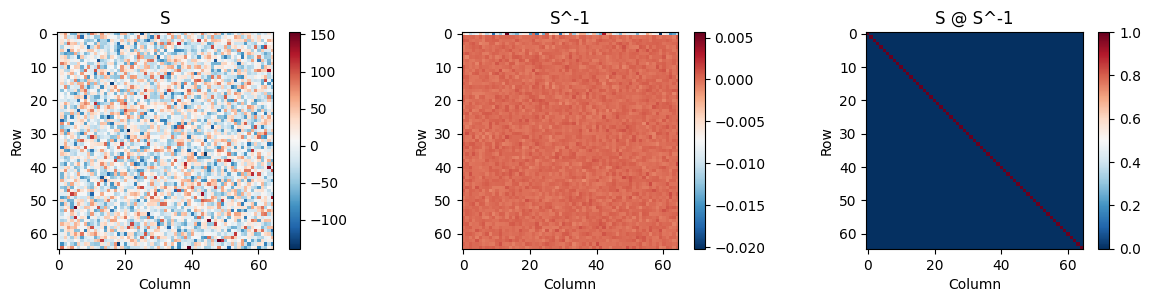

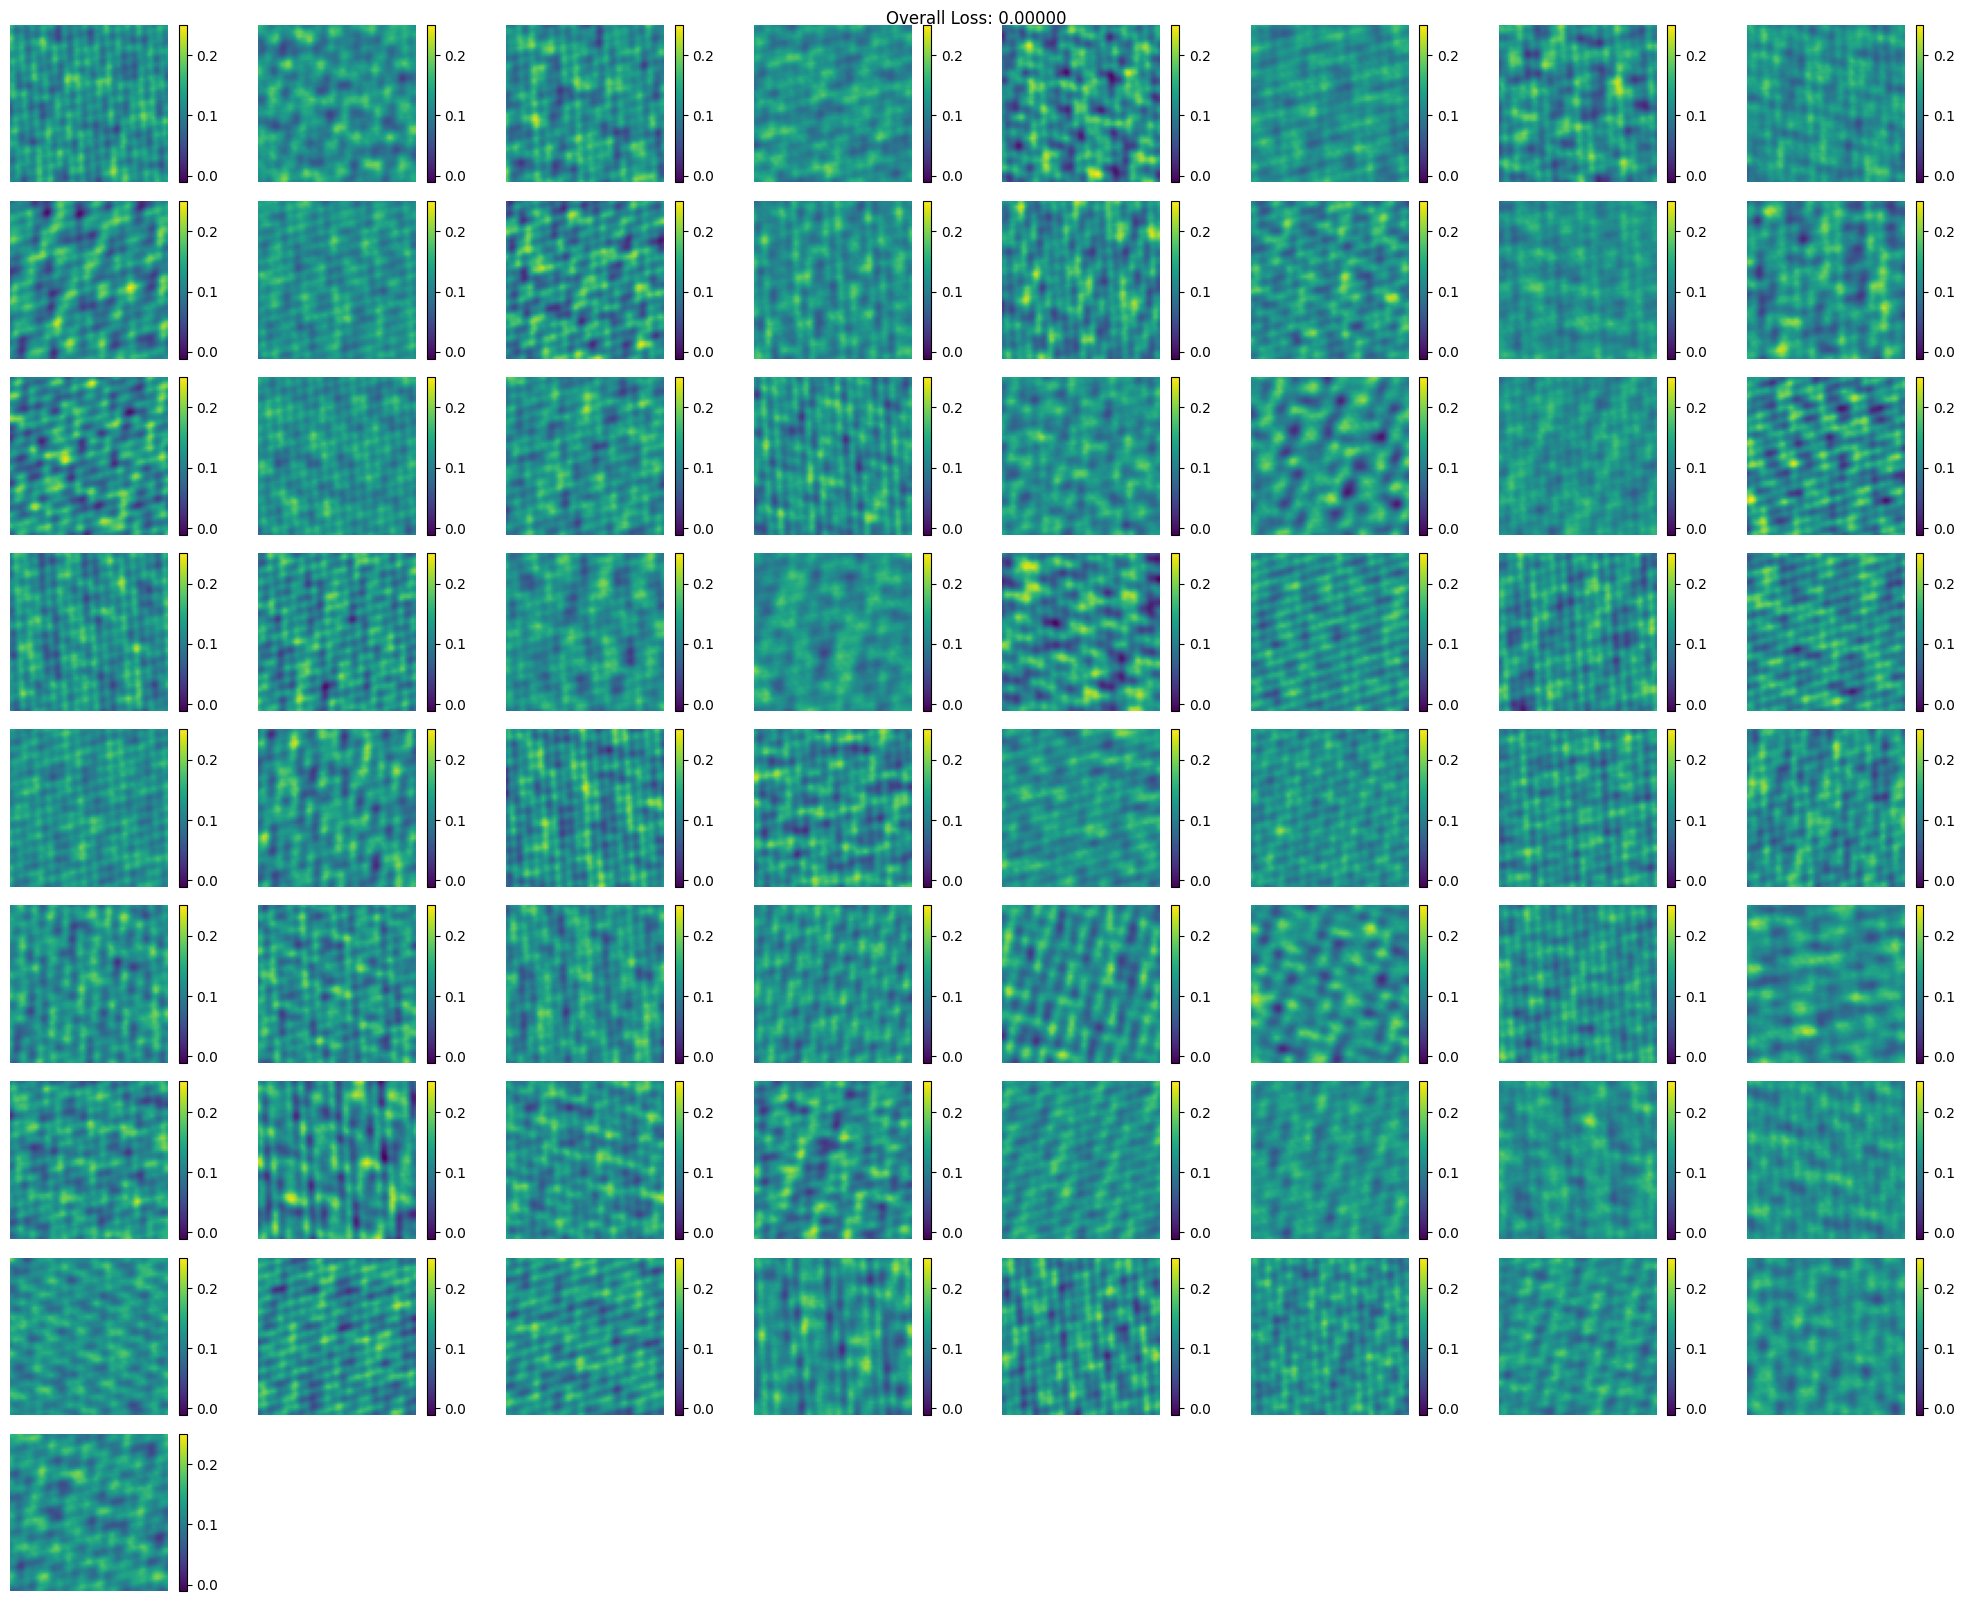

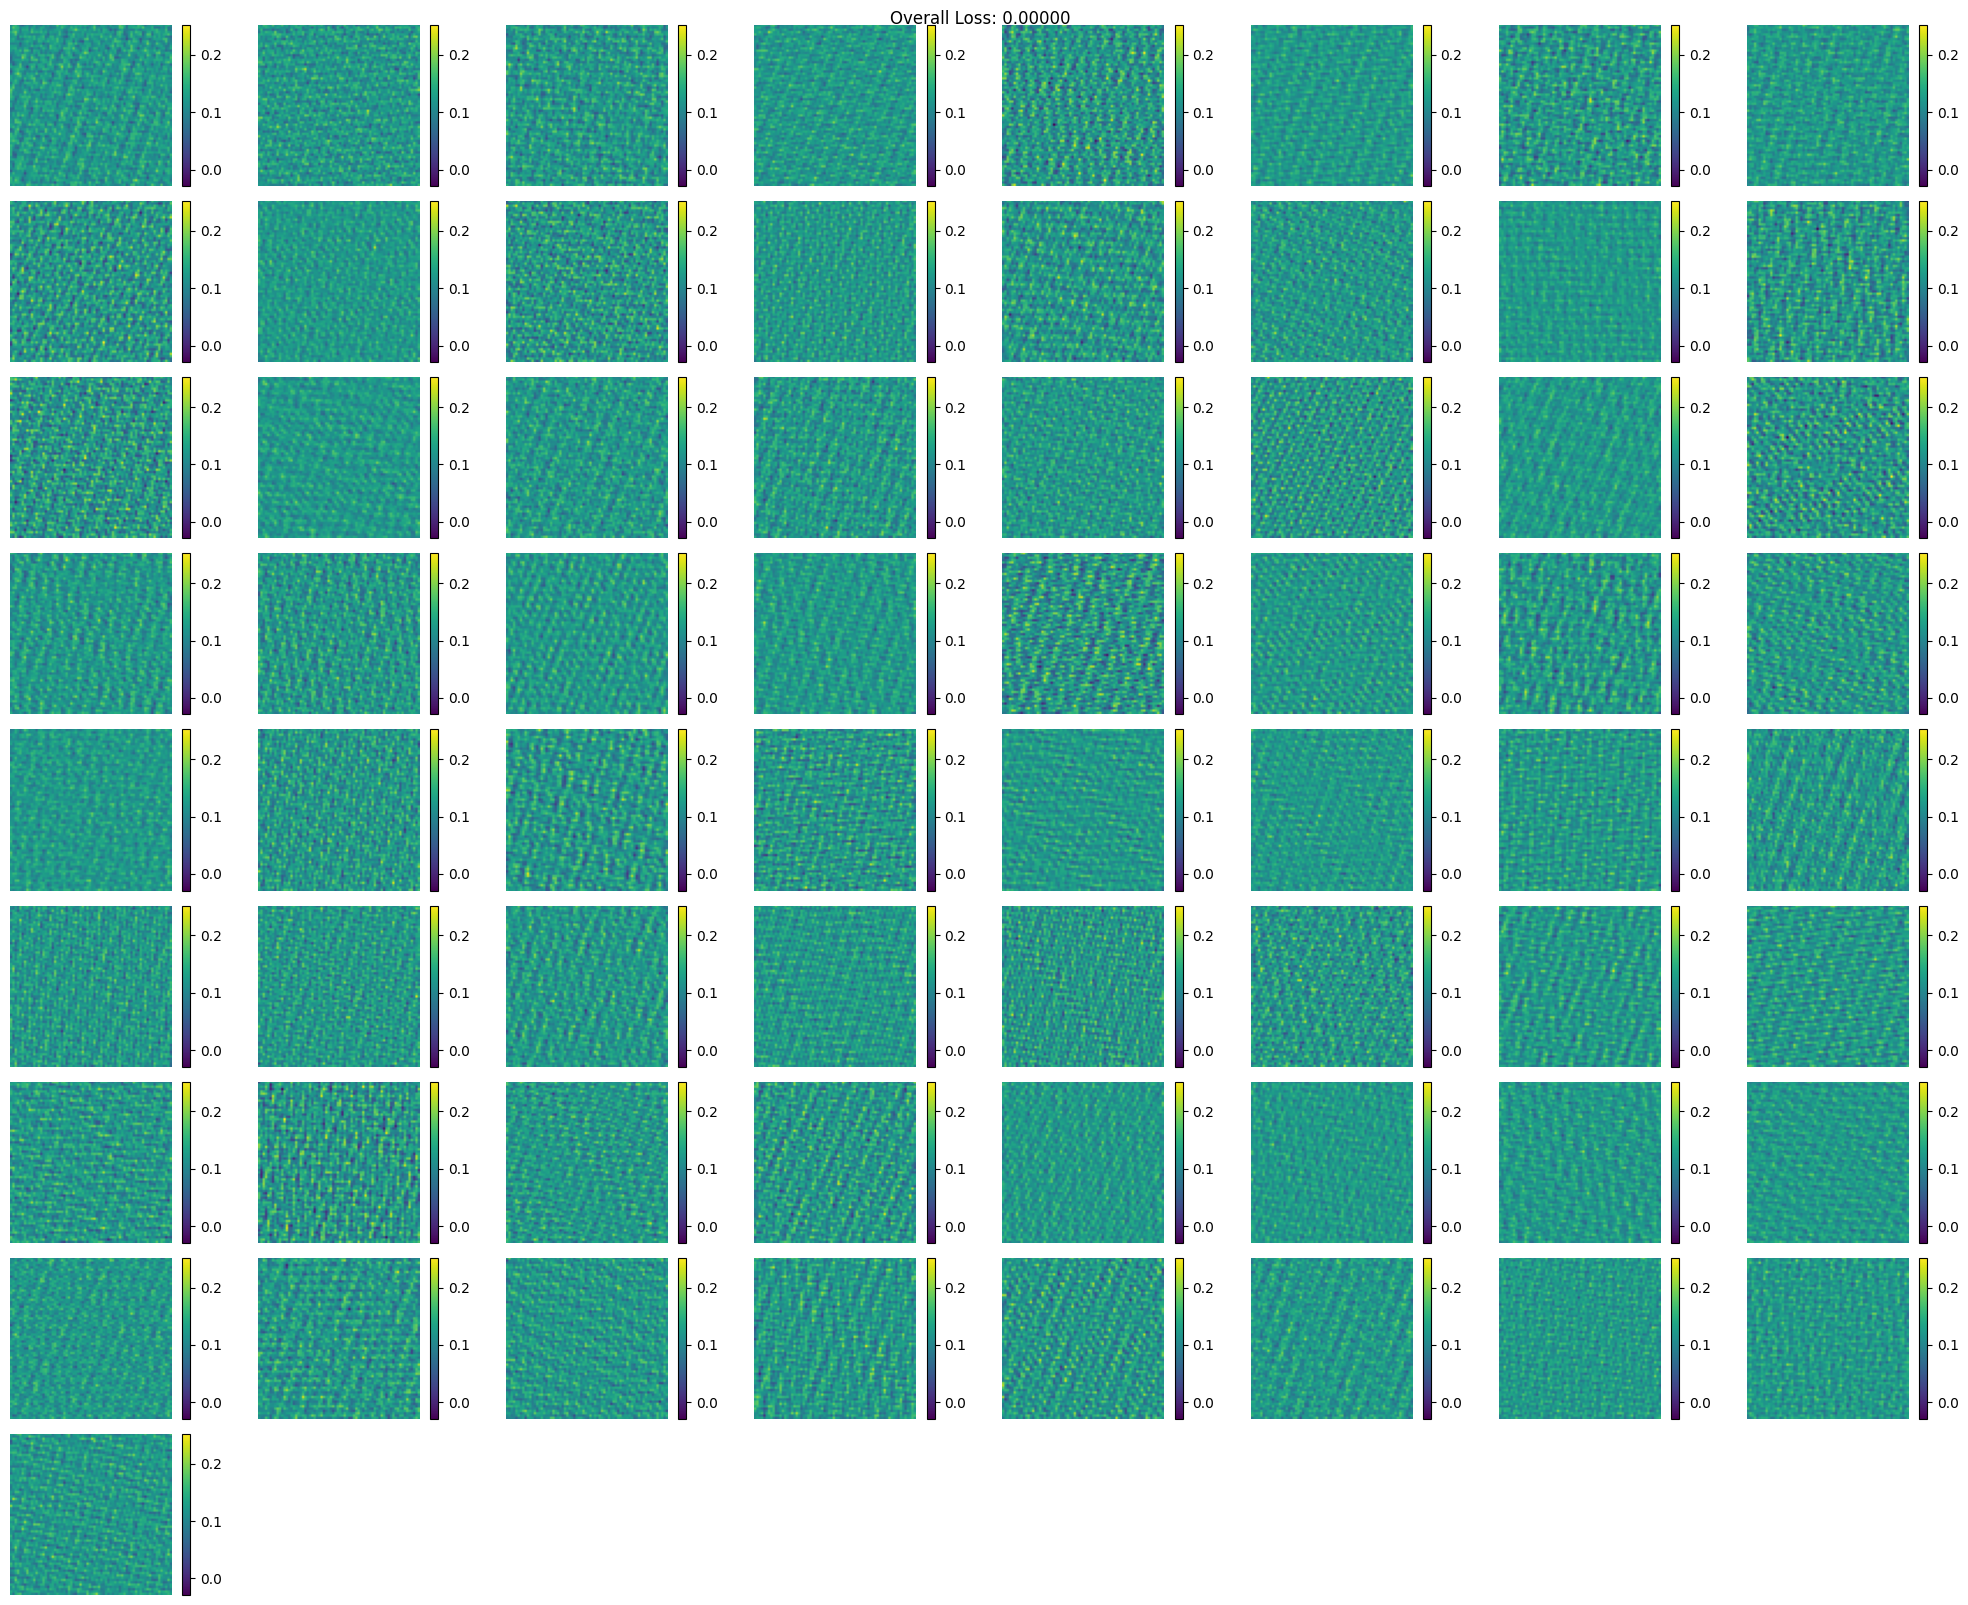

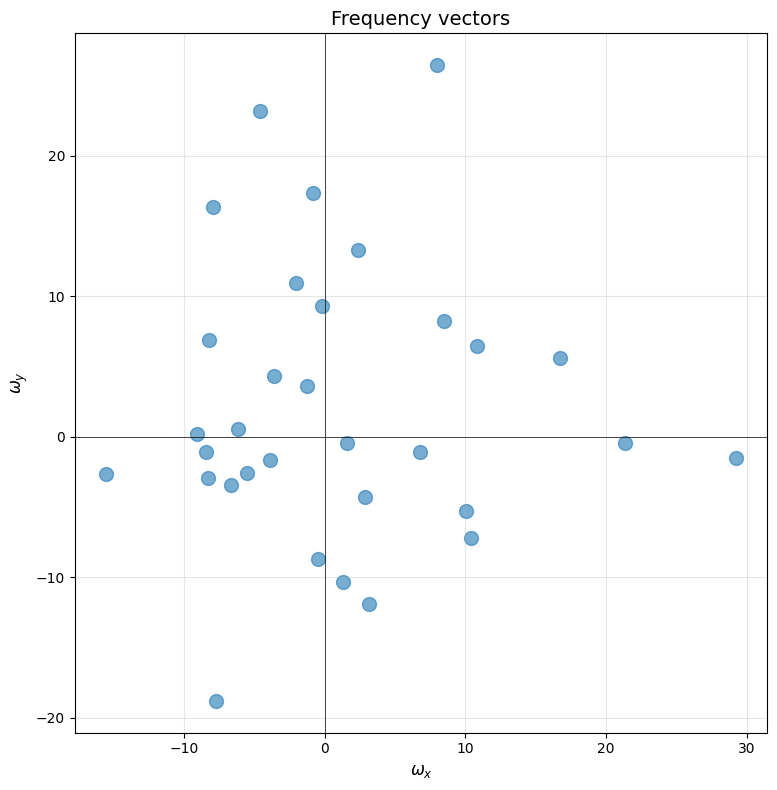

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [5]:
# Visualize 2D plane results using generate_2d_plots from sweep_analysis_sequential
if parameters["dim"] == 2:
    # Get current directory for savepath
    savepath = os.getcwd()
    
    # Generate all 2D plots using the imported function
    figures = generate_2d_plots(g0, om, S, parameters, savepath, counter, plot_scale)
    
    # Display the figures
    for fig_name, fig in figures.items():
        plt.figure(fig.number)
        plt.show()

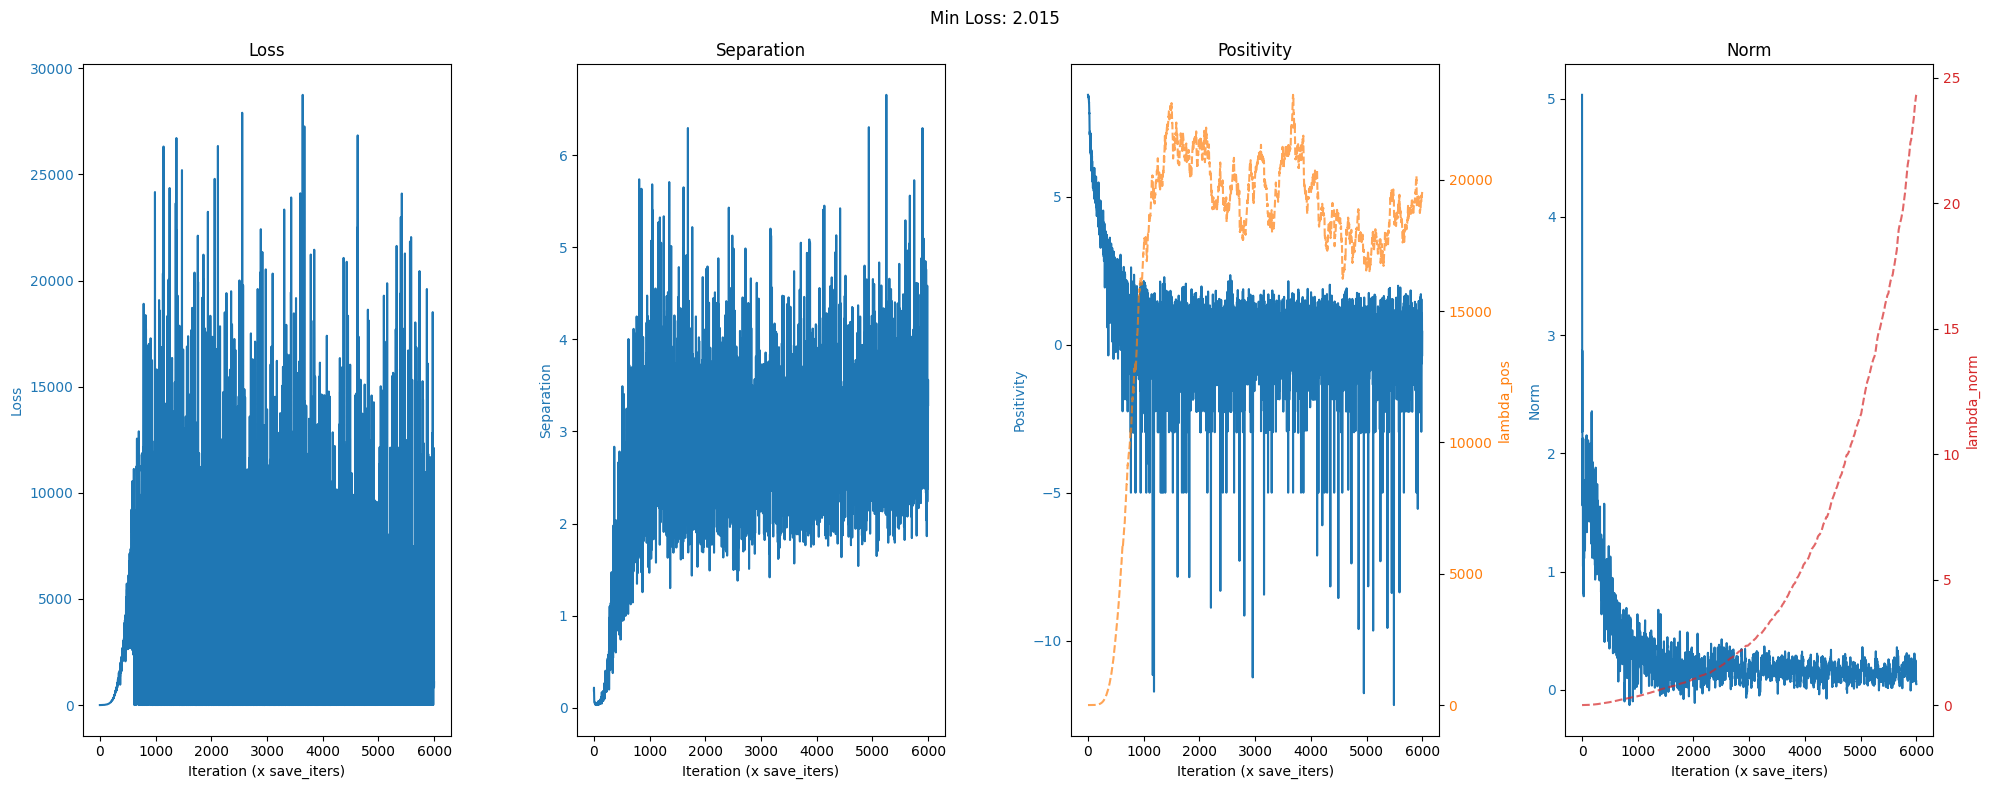

In [3]:
# Plot the loss curves using generate_loss_plots from sweep_analysis_sequential
# Load lambda arrays if they exist
try:
    with open('lambda_pos' + adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        lambda_pos = pickle.load(pickle_file)
except:
    lambda_pos = None

try:
    with open('lambda_norm' + adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        lambda_norm = pickle.load(pickle_file)
except:
    lambda_norm = None

fig_loss = generate_loss_plots(L, min_L, lambda_pos, lambda_norm)
plt.show()

100%|██████████| 65/65 [00:20<00:00,  3.19it/s]


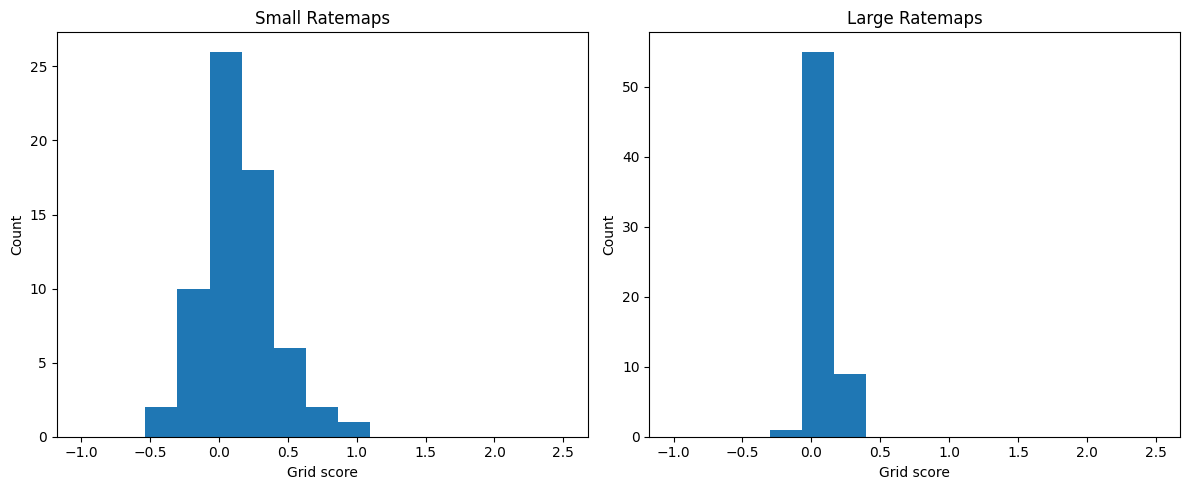

In [10]:
from NRT_functions.analysis import quantitative_analysis_seq

fig_score = quantitative_analysis_seq(g0, S, om, parameters, counter, savepath=os.getcwd())

In [ ]:
# Analyze S matrix structure
print("\nAnalysis of S (change of basis matrix):")
print(f"  Shape: {S.shape}")
print(f"  Frobenius norm: {np.linalg.norm(S):.5f}")
print(f"  Condition number: {np.linalg.cond(S):.5f}")
print(f"  Determinant: {np.linalg.det(S):.5f}")

# Note: S matrix visualization is generated by generate_2d_plots() above

In [ ]:
from DataHandling import TrajectoryGenerator

generator = TrajectoryGenerator()
generator.generate_dataset('dataset/seq_len_25_batch_5/', 50000, batch_size=5, sequence_length=25)

Generating 50000 batches of size 20...
Generated 10/50000 batches
Generated 20/50000 batches
Generated 30/50000 batches
Generated 40/50000 batches
Generated 50/50000 batches
Generated 60/50000 batches
Generated 70/50000 batches
Generated 80/50000 batches
Generated 90/50000 batches
Generated 100/50000 batches
Generated 110/50000 batches
Generated 120/50000 batches
Generated 130/50000 batches
Generated 140/50000 batches
Generated 150/50000 batches
Generated 160/50000 batches
Generated 170/50000 batches
Generated 180/50000 batches
Generated 190/50000 batches
Generated 200/50000 batches
Generated 210/50000 batches
Generated 220/50000 batches
Generated 230/50000 batches
Generated 240/50000 batches
Generated 250/50000 batches
Generated 260/50000 batches
Generated 270/50000 batches
Generated 280/50000 batches
Generated 290/50000 batches
Generated 300/50000 batches
Generated 310/50000 batches
Generated 320/50000 batches
Generated 330/50000 batches
Generated 340/50000 batches
Generated 350/5000